# 👕 Clothing Image Classification with Transfer Learning
### Comparing MobileNetV2 vs ResNet18

**Course:** Advanced Machine Learning & Deep Learning  
**Topic:** Transfer Learning for Image Classification  
**Dataset:** Clothing Dataset (GitHub - small subset, 10 classes, ~1,000 images)

---
## 📋 Notebook Overview
This notebook covers:
1. Dataset download directly in Colab (no manual upload needed)
2. Data loading, augmentation, and preprocessing
3. Transfer learning with **MobileNetV2** and **ResNet18**
4. Training, evaluation, and visualization
5. Model comparison table

> ✅ **Runtime:** Make sure to select `Runtime > Change runtime type > T4 GPU` for faster training.

---
## 📦 Step 1: Install and Import Libraries

In [ ]:
# Install timm — a library with many pretrained models including MobileNetV2 and ResNet18
!pip install timm --quiet

# Standard imports
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# TorchVision for datasets and transforms
import torchvision
from torchvision import datasets, transforms

# timm for pretrained models
import timm

# Scikit-learn for evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cuda
   GPU: Tesla T4


---
## 📥 Step 2: Download the Dataset Directly in Colab

We use the **small subset** of the Clothing Dataset from GitHub:  
👉 https://github.com/alexeygrigorev/clothing-dataset-small

This version has **~1,000 images** across **10 classes** — perfect for Colab's free GPU.

**No manual upload or Google Drive needed!** We clone the repo directly.

> 💡 **Alternative options:**
> - **Full dataset (5,000+ images):** Download from Kaggle (`agrigorev/clothing-dataset-full`) and upload to Google Drive, then mount Drive with `from google.colab import drive; drive.mount('/content/drive')`
> - **Upload to Colab directly:** Use `from google.colab import files; files.upload()` to upload a zip file, then `!unzip your_file.zip`

In [ ]:
# Clone the small clothing dataset from GitHub (no login or manual download needed)
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

# The dataset is already organized in train/test/validation folders
# Each folder contains subfolders named after the clothing class
DATA_DIR = '/content/clothing-dataset-small'

# List the contents so we can see the structure
print('\n📁 Dataset folder structure:')
for split in ['train', 'test', 'validation']:
    split_path = os.path.join(DATA_DIR, split)
    if os.path.exists(split_path):
        classes = sorted(os.listdir(split_path))
        total = sum(len(os.listdir(os.path.join(split_path, c))) for c in classes if os.path.isdir(os.path.join(split_path, c)))
        print(f'  {split}/  ({total} images, {len(classes)} classes)')
        for c in classes:
            n = len(os.listdir(os.path.join(split_path, c)))
            print(f'    └─ {c}: {n} images')

Cloning into 'clothing-dataset-small'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 3839 (delta 9), reused 385 (delta 0), pack-reused 3439 (from 1)
Receiving objects: 100% (3839/3839), 100.58 MiB | 8.26 MiB/s, done.
Resolving deltas: 100% (10/10), done.

📁 Dataset folder structure:
  train/  (3068 images, 10 classes)
    └─ dress: 241 images
    └─ hat: 123 images
    └─ longsleeve: 455 images
    └─ outwear: 184 images
    └─ pants: 468 images
    └─ shirt: 290 images
    └─ shoes: 198 images
    └─ shorts: 202 images
    └─ skirt: 112 images
    └─ t-shirt: 795 images
  test/  (372 images, 10 classes)
    └─ dress: 15 images
    └─ hat: 12 images
    └─ longsleeve: 72 images
    └─ outwear: 38 images
    └─ pants: 42 images
    └─ shirt: 26 images
    └─ shoes: 73 images
    └─ shorts: 30 images
    └─ skirt: 12 images
    └─ t-shirt: 52 images
  validation/  (341 images, 10

---
## 🔧 Step 3: Configuration — Set Hyperparameters Here

In [ ]:
# ─────────────────────────────────────────────
# CONFIGURATION — tweak these as needed
# ─────────────────────────────────────────────

IMG_SIZE    = 224      # Both MobileNetV2 and ResNet18 expect 224x224 input
BATCH_SIZE  = 32       # Small batch size for Colab free GPU memory
NUM_EPOCHS  = 10       # Keep low for fast training; increase for better accuracy
LR          = 0.001    # Learning rate for the classifier head
VAL_SPLIT   = 0.2      # 20% of training data used for validation (if no val folder)
SEED        = 42       # For reproducibility

# Set seeds so results are reproducible
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print('⚙️  Configuration set!')
print(f'   Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Epochs     : {NUM_EPOCHS}')
print(f'   Learn. rate: {LR}')

⚙️  Configuration set!
   Image size : 224x224
   Batch size : 32
   Epochs     : 10
   Learn. rate: 0.001


---
## 🔄 Step 4: Data Transforms (Preprocessing + Augmentation)

In [ ]:
# ImageNet mean and std — used to normalize images the same way pretrained models were trained
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Training transforms: include data augmentation to prevent overfitting ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),    # Resize image to 224x224
    transforms.RandomHorizontalFlip(),          # Randomly flip image left-right (augmentation)
    transforms.RandomRotation(10),              # Randomly rotate by up to 10 degrees (augmentation)
    transforms.ColorJitter(brightness=0.2,      # Slightly vary brightness/contrast (augmentation)
                           contrast=0.2),
    transforms.ToTensor(),                      # Convert PIL image to PyTorch tensor (0-1 range)
    transforms.Normalize(mean=IMAGENET_MEAN,    # Normalize using ImageNet stats
                         std=IMAGENET_STD)
])

# --- Validation/Test transforms: NO augmentation, just resize and normalize ---
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('✅ Transforms defined!')

✅ Transforms defined!


---
## 🗂️ Step 5: Load the Dataset

In [ ]:
# ImageFolder automatically reads the folder structure:
#   /train/dress/img1.jpg  → class: 'dress'
#   /train/shirt/img2.jpg  → class: 'shirt'  ... etc.

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, 'train'),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, 'validation'),
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, 'test'),
    transform=val_transforms
)

# Class names and count
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'✅ Dataset loaded!')
print(f'   Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'   Train images    : {len(train_dataset)}')
print(f'   Validation images: {len(val_dataset)}')
print(f'   Test images     : {len(test_dataset)}')

# Create DataLoaders — these handle batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

✅ Dataset loaded!
   Classes (10): ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
   Train images    : 3068
   Validation images: 341
   Test images     : 372


---
## 🖼️ Step 6: Visualize Sample Dataset Images

/tmp/ipykernel_3284/2471803171.py:30: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3284/2471803171.py:31: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


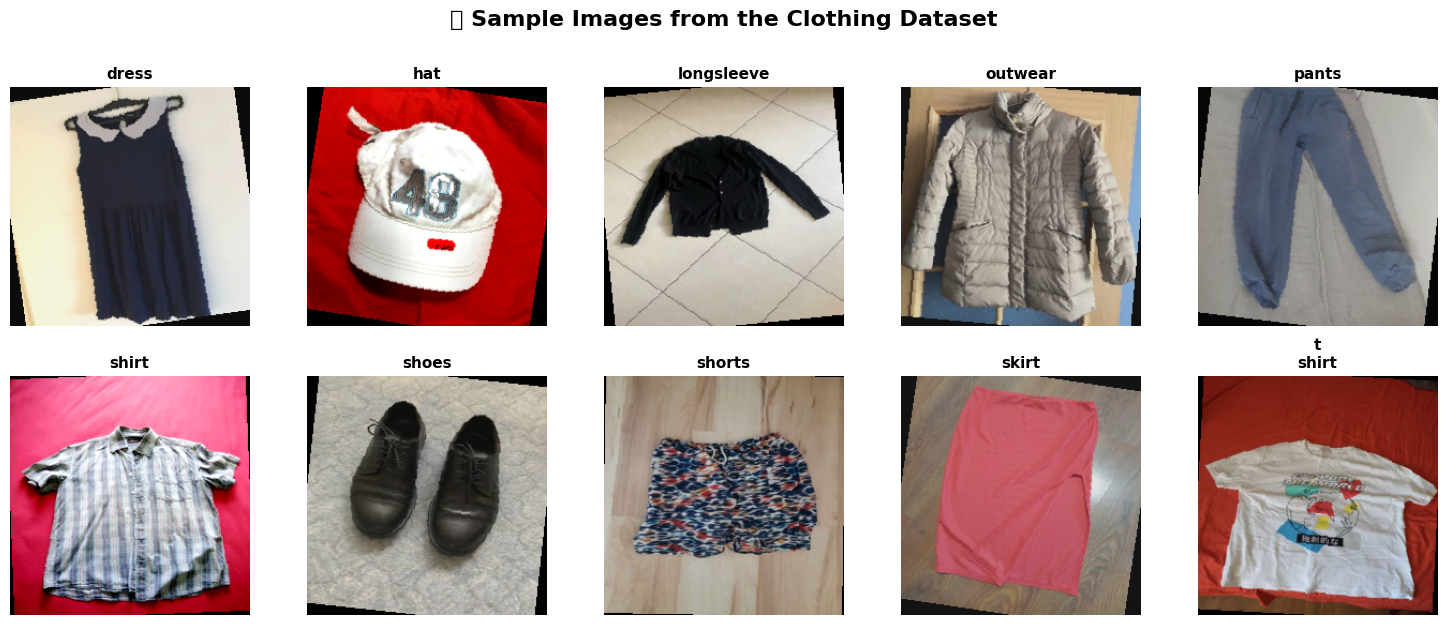

✅ Figure saved as sample_images.png


In [ ]:
def denormalize(tensor):
    """Reverse normalization so we can display images properly."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Show a grid of sample images from the training set
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('📸 Sample Images from the Clothing Dataset', fontsize=16, fontweight='bold', y=1.01)

# Pick one image per class
shown = {}
for img, label in train_dataset:
    cls = CLASS_NAMES[label]
    if cls not in shown:
        shown[cls] = img
    if len(shown) == NUM_CLASSES:
        break

for ax, (cls, img) in zip(axes.flat, shown.items()):
    img_display = denormalize(img).permute(1, 2, 0).numpy()  # CHW → HWC for matplotlib
    ax.imshow(img_display)
    ax.set_title(cls.replace('-', '\n'), fontsize=11, fontweight='bold')
    ax.axis('off')

# Hide unused subplots if any
for ax in axes.flat[len(shown):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figure saved as sample_images.png')

---
## 🧠 Step 7: Define Transfer Learning Model Builder

**Transfer Learning Concept:**
- A model pretrained on ImageNet already knows edges, textures, shapes, and patterns.
- We **freeze** those layers so their weights don't change during training.
- We **replace** only the final classification layer with our own (for our 10 clothing classes).
- We train only that new head — fast and effective even with a small dataset!

In [ ]:
def build_model(model_name, num_classes):
    """
    Load a pretrained model, freeze all layers, and replace
    the final classification head for our number of classes.

    Args:
        model_name: 'mobilenetv2_100' or 'resnet18'
        num_classes: number of clothing categories

    Returns:
        model ready for fine-tuning
    """
    # Load model with ImageNet pretrained weights (pretrained=True)
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    # FREEZE all layers — we don't want to modify what the model already learned
    for param in model.parameters():
        param.requires_grad = False

    # UNFREEZE only the final classifier head so only it gets trained
    # timm models expose the final layer as model.classifier or model.fc
    if hasattr(model, 'classifier'):
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif hasattr(model, 'fc'):
        for param in model.fc.parameters():
            param.requires_grad = True

    return model


def count_params(model):
    """Count trainable and total parameters in a model."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# Test build
for name in ['mobilenetv2_100', 'resnet18']:
    m = build_model(name, NUM_CLASSES)
    total, trainable = count_params(m)
    print(f'{name}:')
    print(f'  Total params     : {total:,}')
    print(f'  Trainable params : {trainable:,}  ← only the new head')
    print(f'  Frozen params    : {total - trainable:,}  ← pretrained backbone')
    print()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

mobilenetv2_100:
  Total params     : 2,236,682
  Trainable params : 12,810  ← only the new head
  Frozen params    : 2,223,872  ← pretrained backbone



model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

resnet18:
  Total params     : 11,181,642
  Trainable params : 5,130  ← only the new head
  Frozen params    : 11,176,512  ← pretrained backbone



---
## 🚂 Step 8: Training and Evaluation Functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one epoch of training. Returns average loss and accuracy."""
    model.train()         # Set model to training mode (enables dropout, batchnorm updates)
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)  # Move data to GPU

        optimizer.zero_grad()          # Reset gradients from previous step
        outputs = model(images)        # Forward pass: get predictions
        loss = criterion(outputs, labels)  # Compute how wrong the predictions are
        loss.backward()                # Backward pass: compute gradients
        optimizer.step()               # Update weights using gradients

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)  # Pick the class with highest score
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset. Returns loss, accuracy, true labels, predicted labels."""
    model.eval()          # Set model to evaluation mode (disables dropout etc.)
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():  # Don't compute gradients — saves memory and speeds up
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_labels, all_preds


def train_model(model_name, num_epochs=NUM_EPOCHS):
    """
    Full training loop for a given model.
    Returns: trained model, history dict, training time in seconds
    """
    print(f'\n{'='*55}')
    print(f'  Training: {model_name}')
    print(f'{'='*55}')

    # Build model and move to GPU/CPU
    model = build_model(model_name, NUM_CLASSES).to(device)

    # Loss function: CrossEntropyLoss is standard for multi-class classification
    criterion = nn.CrossEntropyLoss()

    # Optimizer: only pass trainable parameters (the new classifier head)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        # Train for one epoch
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        # Evaluate on validation set
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)

        # Save history for plotting
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f'  Epoch [{epoch:02d}/{num_epochs}]  '
              f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
              f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}')

    elapsed = time.time() - start_time
    print(f'\n  ⏱️  Training completed in {elapsed:.1f} seconds')
    return model, history, elapsed

print('✅ Training functions defined!')

✅ Training functions defined!


---
## 🏃 Step 9: Train MobileNetV2

In [ ]:
mobilenet_model, mobilenet_history, mobilenet_time = train_model('mobilenetv2_100')


  Training: mobilenetv2_100
  Epoch [01/10]  Train Loss: 2.9759  Train Acc: 0.2363  Val Loss: 2.4082  Val Acc: 0.3138
  Epoch [02/10]  Train Loss: 1.8842  Train Acc: 0.4394  Val Loss: 1.7545  Val Acc: 0.4839
  Epoch [03/10]  Train Loss: 1.4720  Train Acc: 0.5310  Val Loss: 1.4476  Val Acc: 0.5484
  Epoch [04/10]  Train Loss: 1.2387  Train Acc: 0.6010  Val Loss: 1.2548  Val Acc: 0.5924
  Epoch [05/10]  Train Loss: 1.0955  Train Acc: 0.6512  Val Loss: 1.1505  Val Acc: 0.6481
  Epoch [06/10]  Train Loss: 1.0019  Train Acc: 0.6714  Val Loss: 1.0621  Val Acc: 0.6569
  Epoch [07/10]  Train Loss: 0.8954  Train Acc: 0.7005  Val Loss: 1.0399  Val Acc: 0.6745
  Epoch [08/10]  Train Loss: 0.8519  Train Acc: 0.7223  Val Loss: 0.9658  Val Acc: 0.6833
  Epoch [09/10]  Train Loss: 0.7909  Train Acc: 0.7363  Val Loss: 0.9890  Val Acc: 0.6774
  Epoch [10/10]  Train Loss: 0.7716  Train Acc: 0.7480  Val Loss: 0.9082  Val Acc: 0.6979

  ⏱️  Training completed in 194.0 seconds


---
## 🏃 Step 10: Train ResNet18

In [ ]:
resnet_model, resnet_history, resnet_time = train_model('resnet18')


  Training: resnet18
  Epoch [01/10]  Train Loss: 1.9634  Train Acc: 0.3220  Val Loss: 1.7675  Val Acc: 0.4018
  Epoch [02/10]  Train Loss: 1.6120  Train Acc: 0.4980  Val Loss: 1.4851  Val Acc: 0.5777
  Epoch [03/10]  Train Loss: 1.3934  Train Acc: 0.5896  Val Loss: 1.3118  Val Acc: 0.6305
  Epoch [04/10]  Train Loss: 1.2569  Train Acc: 0.6346  Val Loss: 1.1889  Val Acc: 0.6364
  Epoch [05/10]  Train Loss: 1.1550  Train Acc: 0.6604  Val Loss: 1.1011  Val Acc: 0.6891
  Epoch [06/10]  Train Loss: 1.0798  Train Acc: 0.6917  Val Loss: 1.0445  Val Acc: 0.6979
  Epoch [07/10]  Train Loss: 1.0028  Train Acc: 0.7164  Val Loss: 0.9646  Val Acc: 0.7361
  Epoch [08/10]  Train Loss: 0.9695  Train Acc: 0.7203  Val Loss: 0.9447  Val Acc: 0.7155
  Epoch [09/10]  Train Loss: 0.9231  Train Acc: 0.7301  Val Loss: 0.8976  Val Acc: 0.7361
  Epoch [10/10]  Train Loss: 0.8973  Train Acc: 0.7259  Val Loss: 0.8541  Val Acc: 0.7449

  ⏱️  Training completed in 189.4 seconds


---
## 📊 Step 11: Plot Training Curves (Accuracy & Loss)

/tmp/ipykernel_3284/4199886925.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3284/4199886925.py:36: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


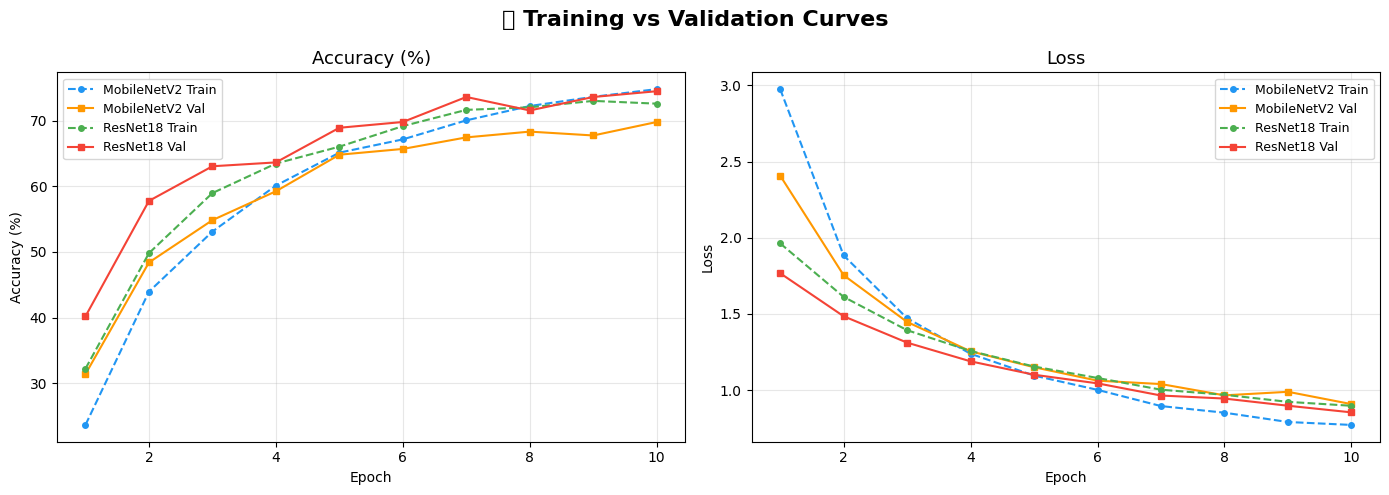

✅ Figure saved as training_curves.png


In [ ]:
def plot_training_curves(histories, model_names):
    """Plot training/validation accuracy and loss for all models side by side."""

    colors = [('#2196F3', '#FF9800'), ('#4CAF50', '#F44336')]  # Blue/Orange for MobileNet, Green/Red for ResNet
    epochs = range(1, NUM_EPOCHS + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('📈 Training vs Validation Curves', fontsize=16, fontweight='bold')

    for i, (history, name, (c_train, c_val)) in enumerate(zip(histories, model_names, colors)):
        # Accuracy plot
        axes[0].plot(epochs, [a*100 for a in history['train_acc']], color=c_train,
                     linestyle='--', marker='o', markersize=4, label=f'{name} Train')
        axes[0].plot(epochs, [a*100 for a in history['val_acc']], color=c_val,
                     linestyle='-', marker='s', markersize=4, label=f'{name} Val')

        # Loss plot
        axes[1].plot(epochs, history['train_loss'], color=c_train,
                     linestyle='--', marker='o', markersize=4, label=f'{name} Train')
        axes[1].plot(epochs, history['val_loss'], color=c_val,
                     linestyle='-', marker='s', markersize=4, label=f'{name} Val')

    axes[0].set_title('Accuracy (%)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Figure saved as training_curves.png')


plot_training_curves(
    [mobilenet_history, resnet_history],
    ['MobileNetV2', 'ResNet18']
)

---
## 🔍 Step 12: Evaluate on Test Set & Confusion Matrix


📊 MobileNetV2 — Test Results:
   Test Loss     : 0.9453
   Test Accuracy : 68.55%

   Per-Class Report:
              precision    recall  f1-score   support

       dress       0.42      0.53      0.47        15
         hat       0.67      0.50      0.57        12
  longsleeve       0.70      0.65      0.68        72
     outwear       0.81      0.58      0.68        38
       pants       0.84      0.76      0.80        42
       shirt       0.35      0.42      0.39        26
       shoes       0.97      0.90      0.94        73
      shorts       0.57      0.57      0.57        30
       skirt       0.46      0.50      0.48        12
     t-shirt       0.57      0.77      0.66        52

    accuracy                           0.69       372
   macro avg       0.64      0.62      0.62       372
weighted avg       0.71      0.69      0.69       372



/tmp/ipykernel_3284/3672284450.py:26: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3284/3672284450.py:27: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


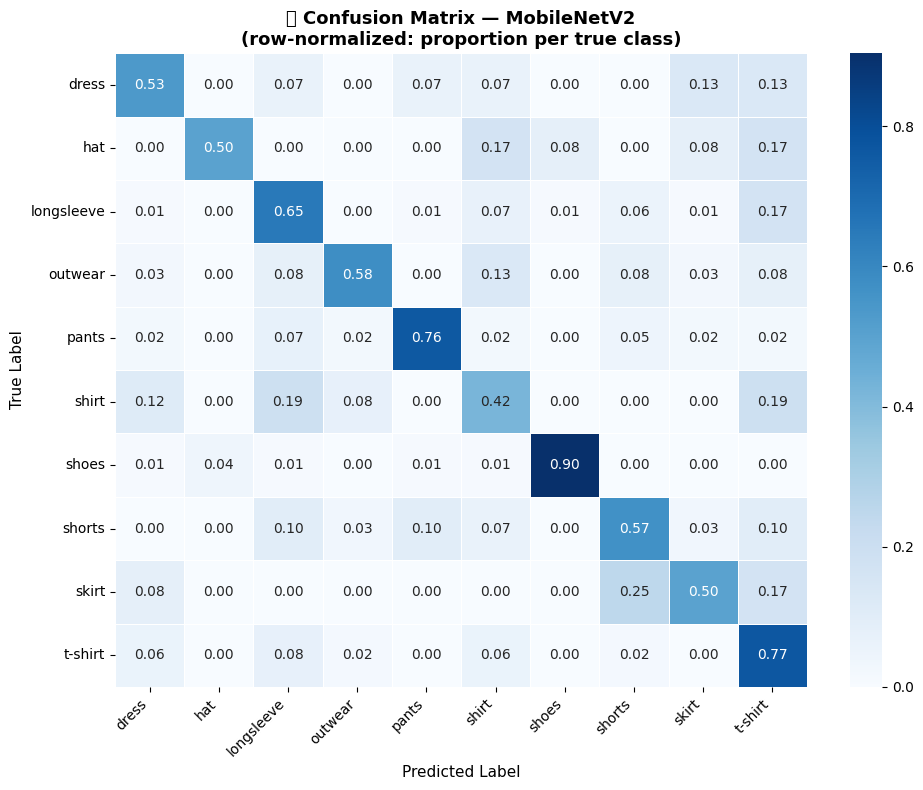

✅ Confusion matrix saved as confusion_mobilenet.png


In [ ]:
def plot_confusion_matrix(model, model_name, loader, class_names, filename):
    """Evaluate model on test set and plot confusion matrix."""
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, true_labels, pred_labels = evaluate(model, loader, criterion, device)

    print(f'\n📊 {model_name} — Test Results:')
    print(f'   Test Loss     : {test_loss:.4f}')
    print(f'   Test Accuracy : {test_acc*100:.2f}%')
    print(f'\n   Per-Class Report:')
    print(classification_report(true_labels, pred_labels, target_names=class_names))

    # Compute and plot confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # Normalize to percentages

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f'🔢 Confusion Matrix — {model_name}\n(row-normalized: proportion per true class)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'✅ Confusion matrix saved as {filename}')

    return test_acc


mobilenet_test_acc = plot_confusion_matrix(
    mobilenet_model, 'MobileNetV2', test_loader, CLASS_NAMES, 'confusion_mobilenet.png'
)


📊 ResNet18 — Test Results:
   Test Loss     : 0.8830
   Test Accuracy : 73.39%

   Per-Class Report:
              precision    recall  f1-score   support

       dress       0.48      0.73      0.58        15
         hat       1.00      0.58      0.74        12
  longsleeve       0.65      0.74      0.69        72
     outwear       0.74      0.45      0.56        38
       pants       0.78      0.93      0.85        42
       shirt       0.62      0.50      0.55        26
       shoes       0.90      0.99      0.94        73
      shorts       0.68      0.43      0.53        30
       skirt       1.00      0.42      0.59        12
     t-shirt       0.69      0.83      0.75        52

    accuracy                           0.73       372
   macro avg       0.75      0.66      0.68       372
weighted avg       0.74      0.73      0.72       372



/tmp/ipykernel_3284/3672284450.py:26: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3284/3672284450.py:27: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


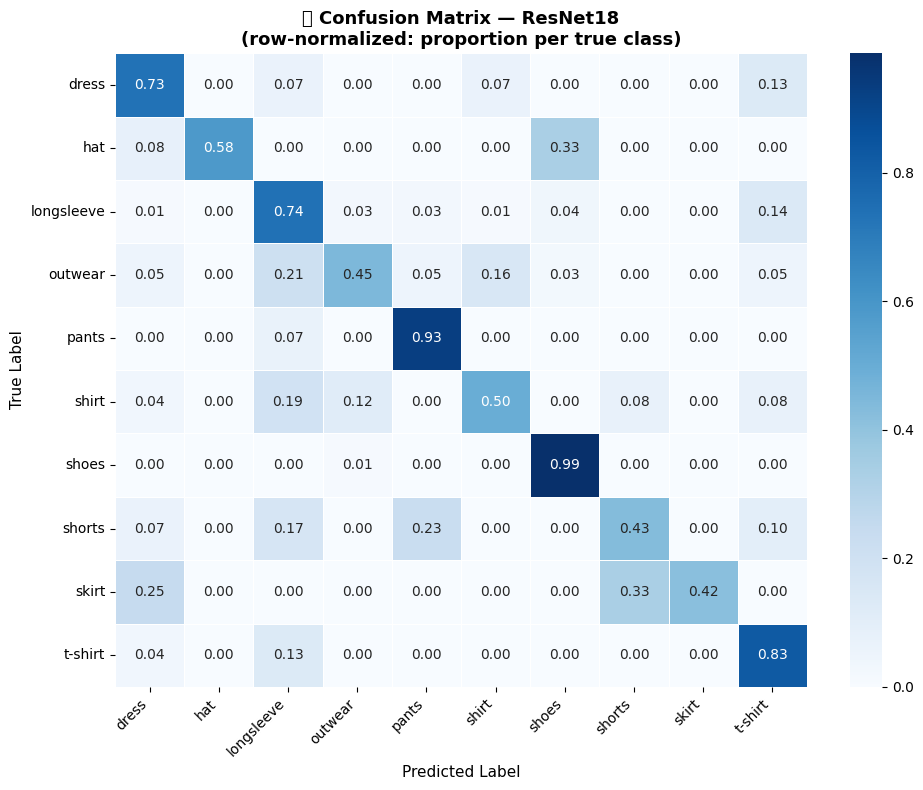

✅ Confusion matrix saved as confusion_resnet.png


In [ ]:
resnet_test_acc = plot_confusion_matrix(
    resnet_model, 'ResNet18', test_loader, CLASS_NAMES, 'confusion_resnet.png'
)

In [ ]:
# ============================================================
# Additional Evaluation Metrics: Precision, Recall, F1-Score
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# MobileNetV2 Metrics
# ------------------------------------------------------------

mobile_test_loss, mobile_test_acc, mobile_true_labels, mobile_pred_labels = evaluate(
    mobilenet_model,
    test_loader,
    nn.CrossEntropyLoss(),
    device
)

mobile_precision = precision_score(
    mobile_true_labels,
    mobile_pred_labels,
    average='weighted'
)

mobile_recall = recall_score(
    mobile_true_labels,
    mobile_pred_labels,
    average='weighted'
)

mobile_f1 = f1_score(
    mobile_true_labels,
    mobile_pred_labels,
    average='weighted'
)

print("=" * 65)
print("📊 MobileNetV2 Additional Metrics")
print("=" * 65)

print(f"Accuracy  : {mobile_test_acc:.4f}")
print(f"Precision : {mobile_precision:.4f}")
print(f"Recall    : {mobile_recall:.4f}")
print(f"F1-Score  : {mobile_f1:.4f}")


# ------------------------------------------------------------
# ResNet18 Metrics
# ------------------------------------------------------------

resnet_test_loss, resnet_test_acc, resnet_true_labels, resnet_pred_labels = evaluate(
    resnet_model,
    test_loader,
    nn.CrossEntropyLoss(),
    device
)

resnet_precision = precision_score(
    resnet_true_labels,
    resnet_pred_labels,
    average='weighted'
)

resnet_recall = recall_score(
    resnet_true_labels,
    resnet_pred_labels,
    average='weighted'
)

resnet_f1 = f1_score(
    resnet_true_labels,
    resnet_pred_labels,
    average='weighted'
)

print("\n" + "=" * 65)
print("📊 ResNet18 Additional Metrics")
print("=" * 65)

print(f"Accuracy  : {resnet_test_acc:.4f}")
print(f"Precision : {resnet_precision:.4f}")
print(f"Recall    : {resnet_recall:.4f}")
print(f"F1-Score  : {resnet_f1:.4f}")

📊 MobileNetV2 Additional Metrics
Accuracy  : 0.6855
Precision : 0.7083
Recall    : 0.6855
F1-Score  : 0.6913

📊 ResNet18 Additional Metrics
Accuracy  : 0.7339
Precision : 0.7445
Recall    : 0.7339
F1-Score  : 0.7236


,Metric,MobileNetV2,ResNet18
0,Accuracy,0.685484,0.733871
1,Precision,0.708296,0.744472
2,Recall,0.685484,0.733871
3,F1-Score,0.691300,0.723570


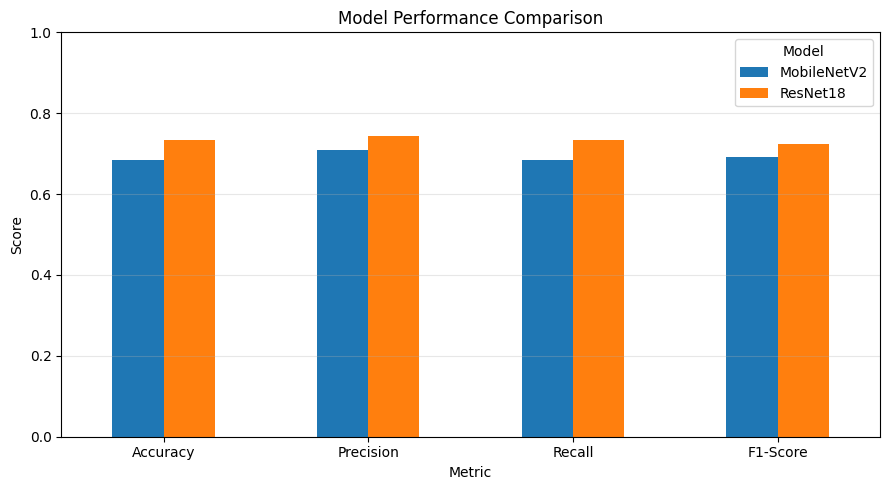

✅ Metrics comparison figure saved as metrics_comparison.png


In [ ]:
# ============================================================
# Visualization: Accuracy, Precision, Recall, and F1-Score
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "MobileNetV2": [mobile_test_acc, mobile_precision, mobile_recall, mobile_f1],
    "ResNet18": [resnet_test_acc, resnet_precision, resnet_recall, resnet_f1]
})

display(metrics_df)

ax = metrics_df.plot(
    x="Metric",
    y=["MobileNetV2", "ResNet18"],
    kind="bar",
    figsize=(9, 5),
    rot=0
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Metrics comparison figure saved as metrics_comparison.png")

---
## 📐 Step 13: Model Size Comparison

In [ ]:
import tempfile

def get_model_size_mb(model):
    """Save model weights to a temp file and return file size in MB."""
    with tempfile.NamedTemporaryFile(suffix='.pt') as f:
        torch.save(model.state_dict(), f.name)
        size_mb = os.path.getsize(f.name) / (1024 ** 2)
    return round(size_mb, 1)

mobilenet_size = get_model_size_mb(mobilenet_model)
resnet_size    = get_model_size_mb(resnet_model)

print(f'MobileNetV2 size: {mobilenet_size} MB')
print(f'ResNet18 size   : {resnet_size} MB')

MobileNetV2 size: 8.8 MB
ResNet18 size   : 42.7 MB


---
## ⚡ Step 14: Inference Speed Test

In [ ]:
def measure_inference_speed(model, n_runs=100):
    """Measure average time to classify a single image batch (ms per image)."""
    model.eval()
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)  # Fake single image

    # Warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)

    # Timed runs
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy_input)
    elapsed = (time.time() - start) / n_runs * 1000  # Convert to ms
    return round(elapsed, 2)

mobilenet_speed = measure_inference_speed(mobilenet_model)
resnet_speed    = measure_inference_speed(resnet_model)

print(f'MobileNetV2 inference speed: {mobilenet_speed} ms/image')
print(f'ResNet18 inference speed   : {resnet_speed} ms/image')

MobileNetV2 inference speed: 8.03 ms/image
ResNet18 inference speed   : 3.03 ms/image


---
## 📋 Step 15: Final Comparison Table

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

# Gather final val accuracy
mobilenet_val_acc = max(mobilenet_history['val_acc'])
resnet_val_acc    = max(resnet_history['val_acc'])

mobilenet_params, _ = count_params(mobilenet_model)
resnet_params, _    = count_params(resnet_model)

# Print formatted comparison table
print('\n' + '='*88)
print('  📊  MODEL COMPARISON TABLE — Transfer Learning on Clothing Dataset')
print('='*88)
print(f"{'Metric':<32} {'MobileNetV2':>20} {'ResNet18':>20}")
print('-'*88)

print(f"{'Val Accuracy (best epoch)':<32} {mobilenet_val_acc*100:>19.2f}% {resnet_val_acc*100:>19.2f}%")
print(f"{'Test Accuracy':<32} {mobilenet_test_acc*100:>19.2f}% {resnet_test_acc*100:>19.2f}%")

print(f"{'Precision':<32} {mobile_precision*100:>19.2f}% {resnet_precision*100:>19.2f}%")
print(f"{'Recall':<32} {mobile_recall*100:>19.2f}% {resnet_recall*100:>19.2f}%")
print(f"{'F1-Score':<32} {mobile_f1*100:>19.2f}% {resnet_f1*100:>19.2f}%")

print(f"{'Training Time (seconds)':<32} {mobilenet_time:>19.1f}s {resnet_time:>19.1f}s")
print(f"{'Model Size (MB)':<32} {mobilenet_size:>19.1f} {resnet_size:>19.1f}")
print(f"{'Inference Speed (ms/img)':<32} {mobilenet_speed:>19.2f} {resnet_speed:>19.2f}")
print(f"{'Total Parameters':<32} {mobilenet_params/1e6:>17.2f}M {resnet_params/1e6:>17.2f}M")

print('='*88)

# Determine winner per metric
better_acc   = 'MobileNetV2' if mobilenet_test_acc > resnet_test_acc else 'ResNet18'
better_f1    = 'MobileNetV2' if mobile_f1 > resnet_f1 else 'ResNet18'
faster_train = 'MobileNetV2' if mobilenet_time < resnet_time else 'ResNet18'
smaller_size = 'MobileNetV2' if mobilenet_size < resnet_size else 'ResNet18'
faster_infer = 'MobileNetV2' if mobilenet_speed < resnet_speed else 'ResNet18'

print(f"  Best Test Accuracy  → {better_acc}")
print(f"  Best F1-Score       → {better_f1}")
print(f"  Faster Training     → {faster_train}")
print(f"  Smaller Model       → {smaller_size}")
print(f"  Faster Inference    → {faster_infer}")

print('='*88)
print()

print('💡 Summary:')
print('  • MobileNetV2 is designed for efficiency: it has fewer parameters,')
print('    smaller file size, and faster inference — ideal for mobile/edge devices')
print('    and quick Colab experiments.')
print('  • ResNet18 uses residual connections which help the model learn')
print('    deeper image representations and achieve stronger classification performance.')
print('  • Precision, Recall, and F1-score were also used to evaluate')
print('    classification quality beyond simple accuracy.')
print('  • For this clothing dataset, ResNet18 achieved the strongest overall')
print('    classification performance, while MobileNetV2 remained more lightweight.')


  📊  MODEL COMPARISON TABLE — Transfer Learning on Clothing Dataset
Metric                                    MobileNetV2             ResNet18
----------------------------------------------------------------------------------------
Val Accuracy (best epoch)                      69.79%               74.49%
Test Accuracy                                  68.55%               73.39%
Precision                                      70.83%               74.45%
Recall                                         68.55%               73.39%
F1-Score                                       69.13%               72.36%
Training Time (seconds)                        194.0s               189.4s
Model Size (MB)                                  8.8                42.7
Inference Speed (ms/img)                        8.03                3.03
Total Parameters                              2.24M             11.18M
  Best Test Accuracy  → ResNet18
  Best F1-Score       → ResNet18
  Faster Training     → ResNet18
 

---
## 📊 Step 16: Visual Comparison Bar Chart

/tmp/ipykernel_3284/459269889.py:37: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3284/459269889.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


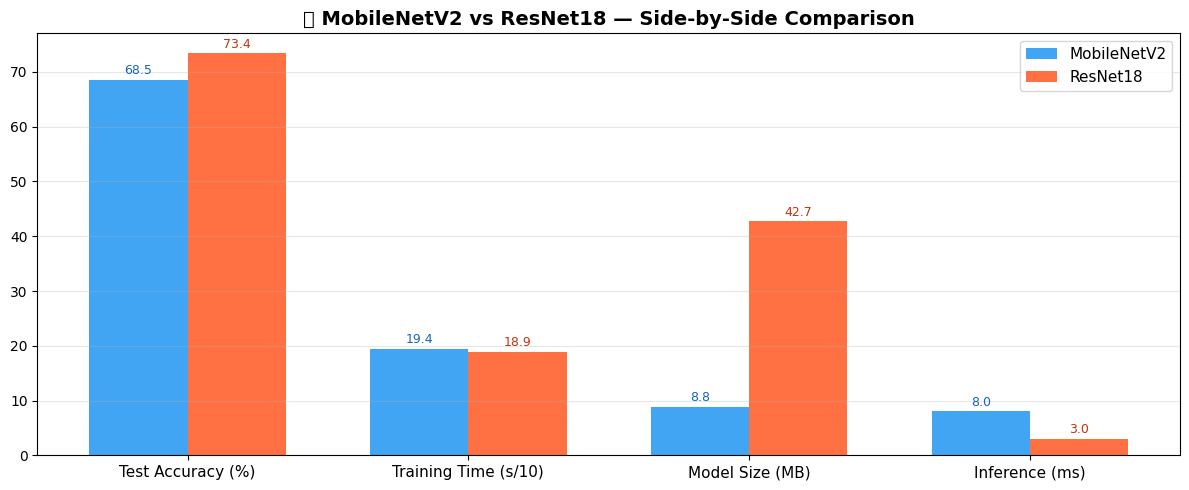

✅ Figure saved as model_comparison.png


In [ ]:
metrics = ['Test Accuracy (%)', 'Training Time (s/10)', 'Model Size (MB)', 'Inference (ms)']

mobilenet_vals = [
    mobilenet_test_acc * 100,
    mobilenet_time / 10,
    mobilenet_size,
    mobilenet_speed
]
resnet_vals = [
    resnet_test_acc * 100,
    resnet_time / 10,
    resnet_size,
    resnet_speed
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, mobilenet_vals, width, label='MobileNetV2', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, resnet_vals,    width, label='ResNet18',    color='#FF5722', alpha=0.85)

ax.set_title('📊 MobileNetV2 vs ResNet18 — Side-by-Side Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, color='#1565C0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, color='#BF360C')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figure saved as model_comparison.png')

---
## 💾 Step 17: Save Trained Models (Optional)

In [ ]:
# Save model weights to disk
# You can download these files from the Colab Files panel (left sidebar)
torch.save(mobilenet_model.state_dict(), 'mobilenet_clothing.pth')
torch.save(resnet_model.state_dict(),    'resnet18_clothing.pth')

print('✅ Models saved!')
print('   mobilenet_clothing.pth')
print('   resnet18_clothing.pth')
print('\n   To download: click the folder icon in the left sidebar → right-click file → Download')

✅ Models saved!
   mobilenet_clothing.pth
   resnet18_clothing.pth

   To download: click the folder icon in the left sidebar → right-click file → Download


---
## ✅ Summary

This notebook demonstrated **transfer learning** for clothing image classification:

| Step | What We Did |
|------|-------------|
| 1 | Installed libraries (timm, PyTorch, torchvision) |
| 2 | Downloaded dataset directly from GitHub — no manual upload needed |
| 3 | Defined preprocessing transforms + augmentation |
| 4 | Loaded images using `ImageFolder` (reads class from folder name) |
| 5 | Built frozen pretrained models, replaced classifier head |
| 6 | Trained both MobileNetV2 and ResNet18 for 10 epochs |
| 7 | Evaluated on test set with accuracy, confusion matrix, classification report |
| 8 | Compared models on accuracy, speed, size, and training time |

**Key takeaway:** Transfer learning lets you achieve good accuracy on small datasets by reusing knowledge from models trained on millions of images. Training only the final layer makes it fast and memory-efficient — perfect for Google Colab!